In [2]:
from pathlib import Path
import pandas as pd
import plotnine as p9
from sqlalchemy import create_engine

DATAFOLDER = Path("../data/")

engine = create_engine("mysql://ssubrahmanya@/personallm?charset=utf8mb4")

/tmp/ipykernel_1944563/586197186.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


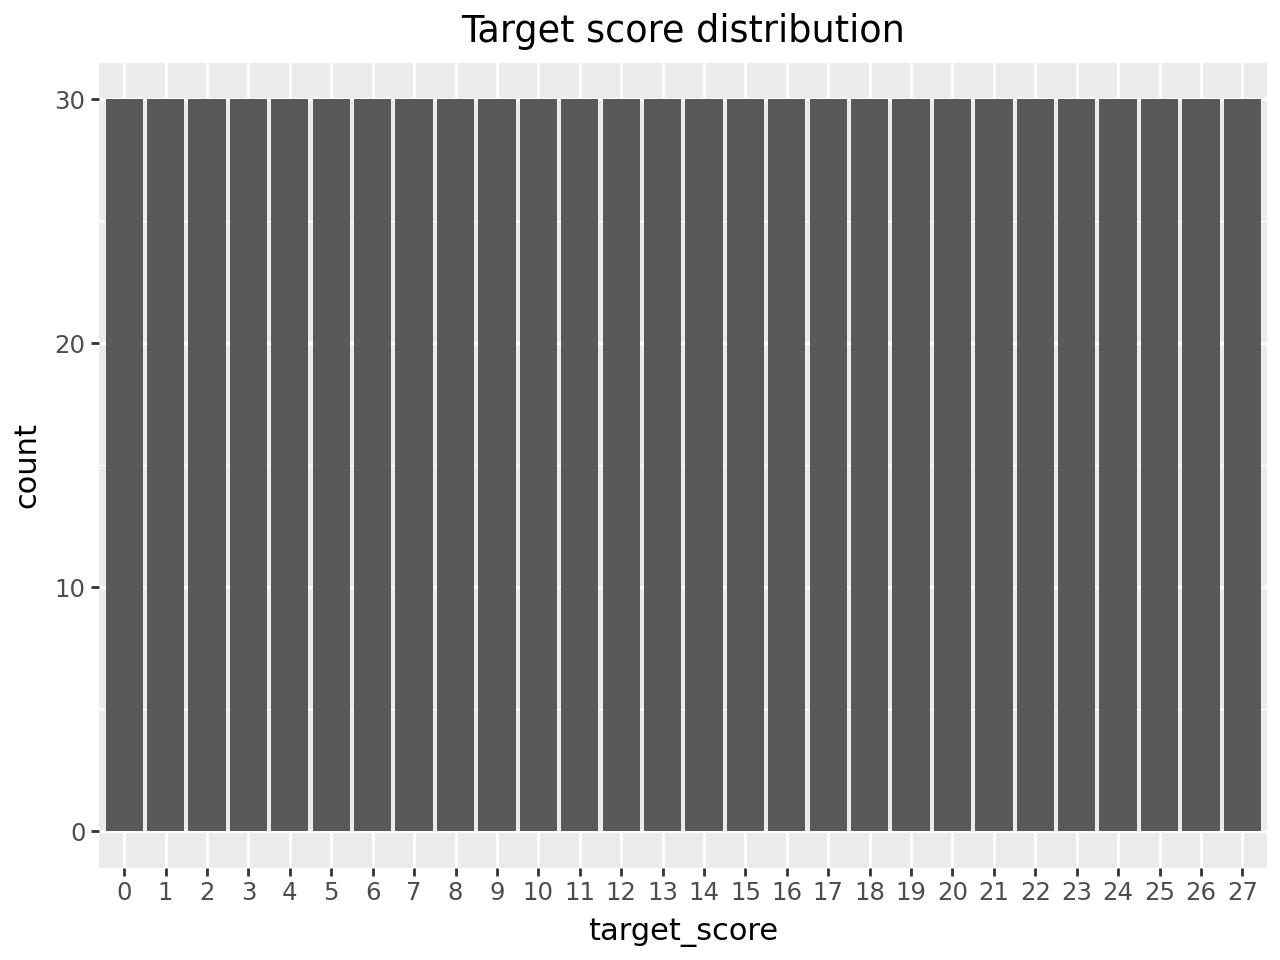

In [10]:
prompts = pd.read_csv(DATAFOLDER / "generated_prompts.csv")

(
    p9.ggplot(prompts, p9.aes(x="factor(target_score)"))
    + p9.geom_bar()
    + p9.labs(x="target_score", y="count", title="Target score distribution")
)

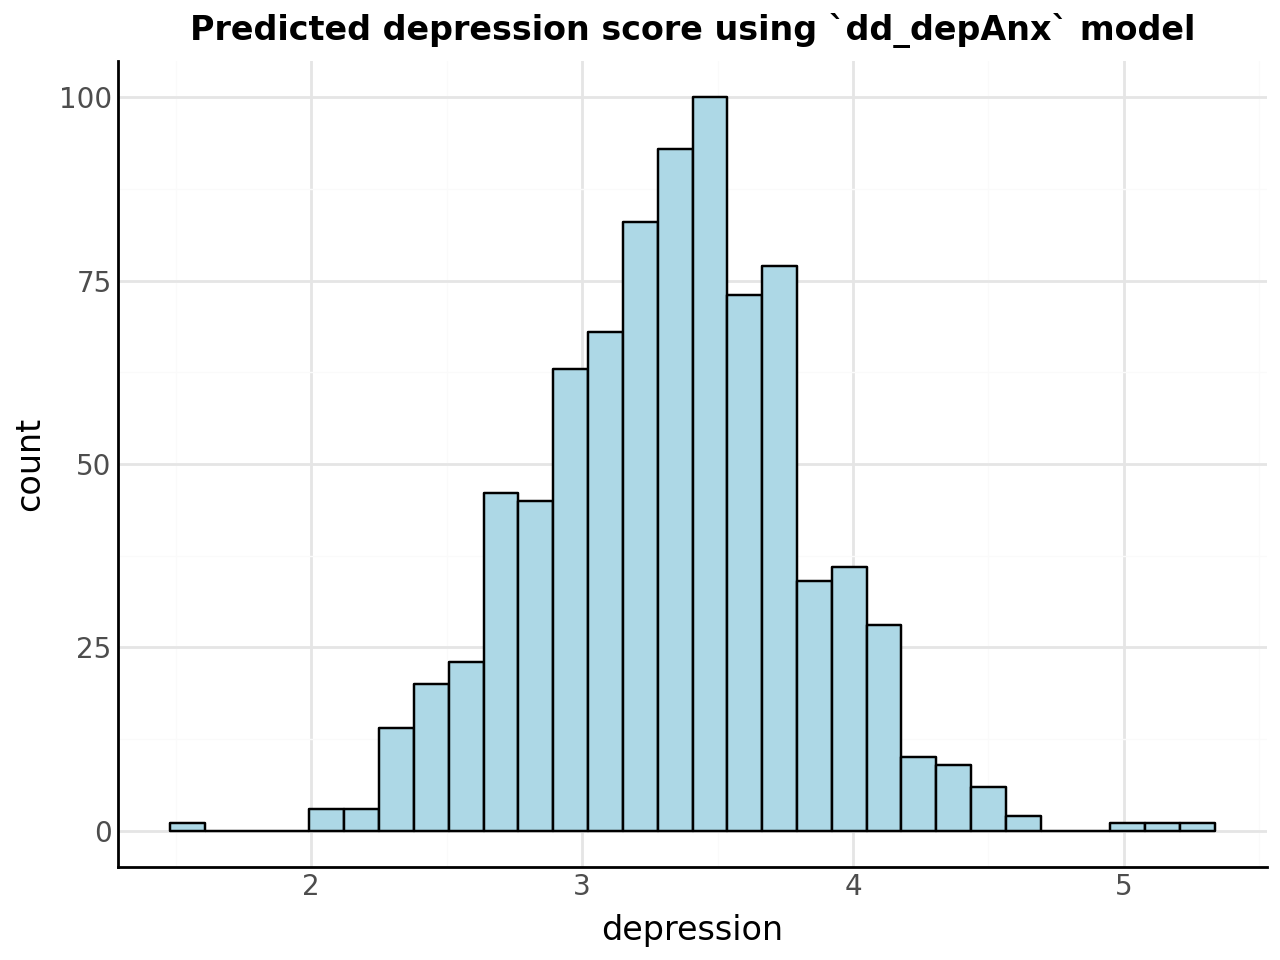

In [4]:
query = "SELECT group_id, group_norm AS depression FROM `feat$cat_dd_depAnx_w$responses$message_id$1gra` WHERE feat = 'DEP_SCORE'"
lbmha = pd.read_sql(query, engine)

dd_depAnx = (
    p9.ggplot(
        data=lbmha, 
        mapping=p9.aes(x="depression")
    ) +
    p9.geom_histogram(
        bins=30, 
        color="black", 
        fill="lightblue"
    ) +
    p9.labs(
        x="depression", 
        y="count", 
        title="Predicted depression score using `dd_depAnx` model"
    ) +
    p9.theme_minimal() +
    p9.theme(
        axis_line= p9.element_line(color="black"),
        axis_title= p9.element_text(size=12),
        axis_text= p9.element_text(size=10),
        plot_title= p9.element_text(size=12, face="bold")
    )
)

dd_depAnx

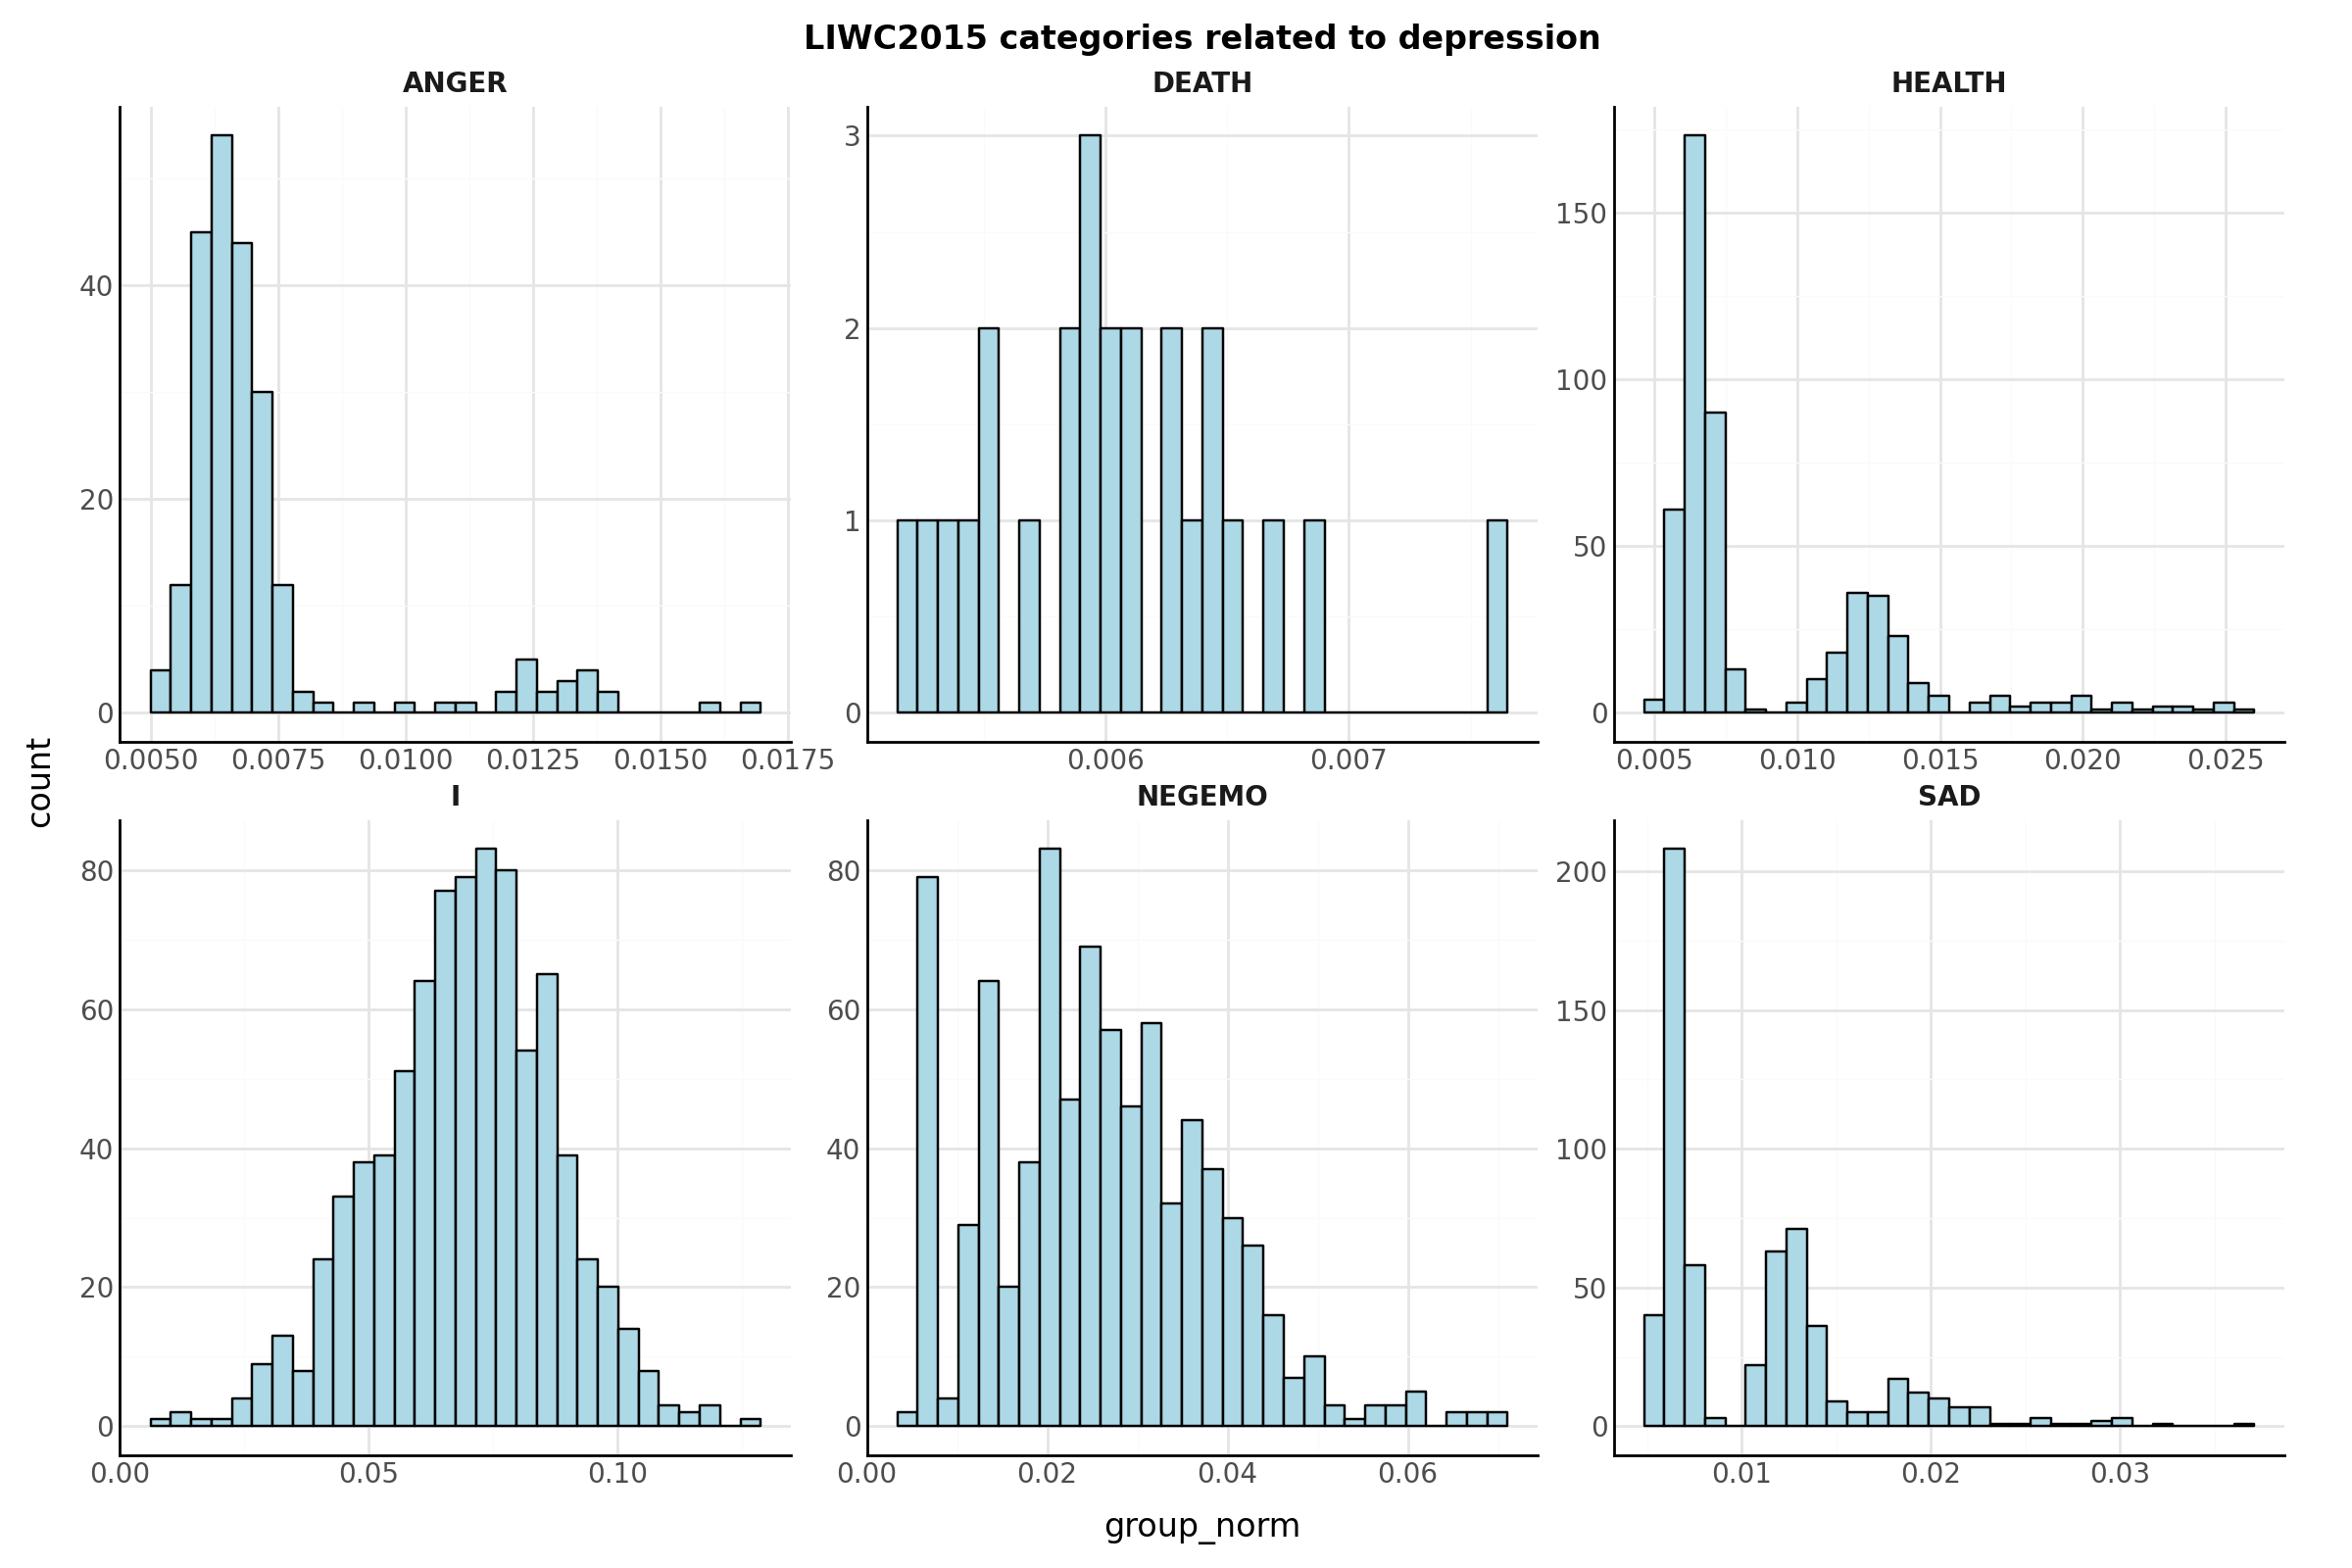

In [5]:
dep_cats = ["I", "NEGEMO", "SAD", "ANGER", "DEATH", "HEALTH"]
anx_cats = ["ANX", "TENTAT", "DISCREP", "NEGATE"]

feats_sql = ", ".join(f"'{f}'" for f in dep_cats + anx_cats)
liwc = pd.read_sql(
    f"SELECT group_id, feat, group_norm FROM `feat$cat_LIWC2015$responses$message_id$1gra` "
    f"WHERE feat IN ({feats_sql})",
    engine,
)

liwc_theme = (
    p9.theme_minimal()
    + p9.theme(
        figure_size=(12, 8),
        axis_line=p9.element_line(color="black"),
        axis_title=p9.element_text(size=12),
        axis_text=p9.element_text(size=10),
        plot_title=p9.element_text(size=12, face="bold"),
        strip_text=p9.element_text(size=10, face="bold"),
    )
)

(
    p9.ggplot(liwc[liwc["feat"].isin(dep_cats)], p9.aes(x="group_norm"))
    + p9.geom_histogram(bins=30, color="black", fill="lightblue")
    + p9.facet_wrap("~ feat", scales="free")
    + p9.labs(x="group_norm", y="count", title="LIWC2015 categories related to depression")
    + liwc_theme
)

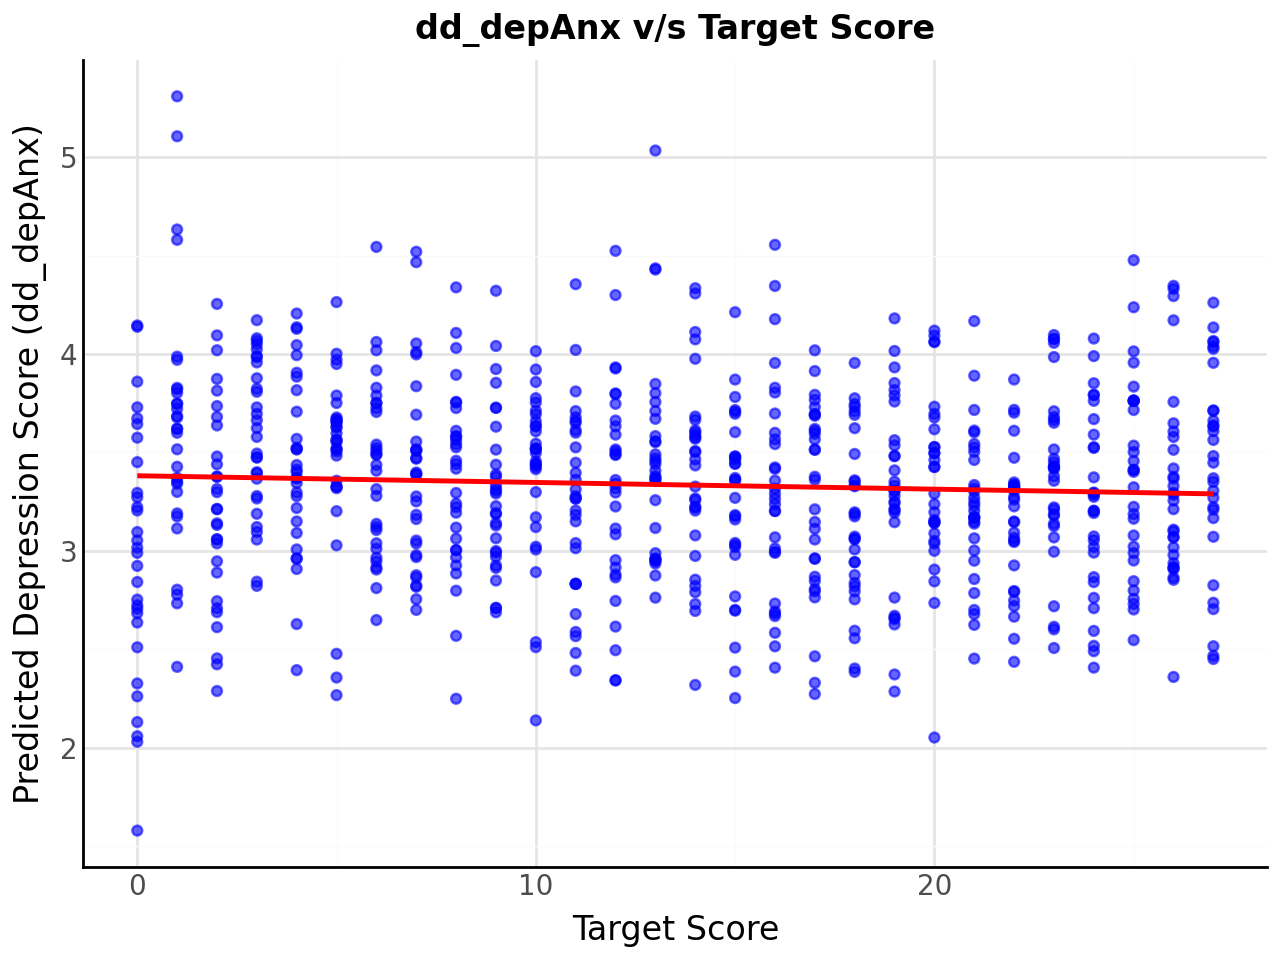

In [12]:
prompts_with_ids = prompts.reset_index(names="group_id")
prompts_with_ids["group_id"] = prompts_with_ids["group_id"].astype(int)

dd_lbmha = pd.merge(prompts_with_ids, lbmha, on="group_id")
dd_depAnx_scatter = (
    p9.ggplot(dd_lbmha, p9.aes(x="target_score", y="depression"))
    + p9.geom_point(color="blue", alpha=0.6)
    + p9.geom_smooth(method="lm", color="red", se=False)
    + p9.labs(
        x="Target Score",
        y="Predicted Depression Score (dd_depAnx)",
        title="dd_depAnx v/s Target Score",
    )
    + p9.theme_minimal()
    + p9.theme(
        axis_line=p9.element_line(color="black"),
        axis_title=p9.element_text(size=12),
        axis_text=p9.element_text(size=10),
        plot_title=p9.element_text(size=12, face="bold"),
    )
)

dd_depAnx_scatter

In [16]:
liwc_lbmha.head()

,group_id,model,target_score,text,error,feat,group_norm
0,0,google/gemini-2.5-flash-lite,2,"September 12th. Woke up feeling okay, just a b...",NaN,ANX,0.007246
1,0,google/gemini-2.5-flash-lite,2,"September 12th. Woke up feeling okay, just a b...",NaN,DISCREP,0.007246
2,0,google/gemini-2.5-flash-lite,2,"September 12th. Woke up feeling okay, just a b...",NaN,HEALTH,0.007246
3,0,google/gemini-2.5-flash-lite,2,"September 12th. Woke up feeling okay, just a b...",NaN,I,0.043478
4,0,google/gemini-2.5-flash-lite,2,"September 12th. Woke up feeling okay, just a b...",NaN,NEGATE,0.014493


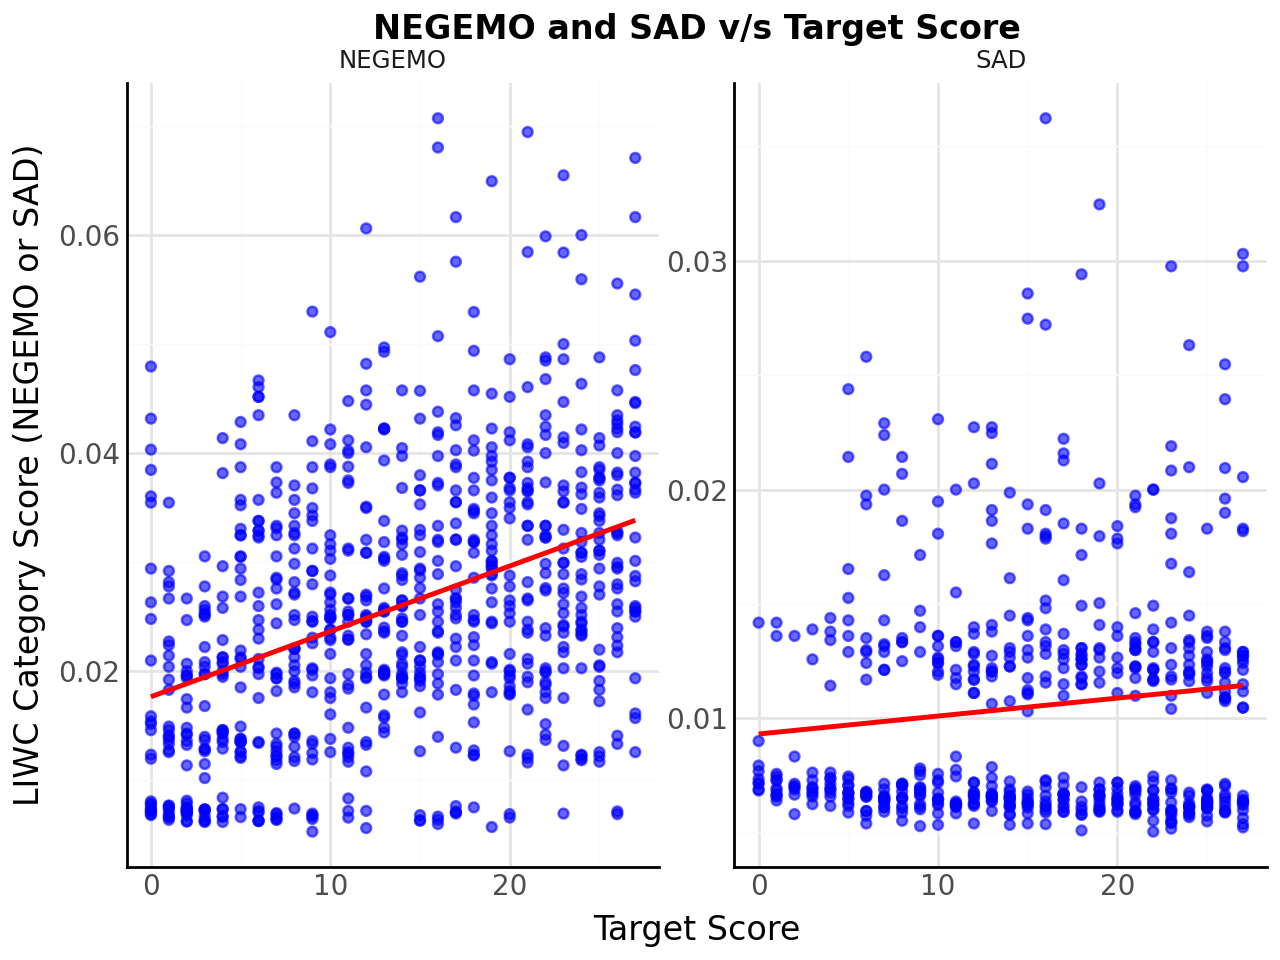

In [19]:
liwc_lbmha = pd.merge(prompts_with_ids, liwc, on="group_id")
liwc_lbmha = liwc_lbmha[liwc_lbmha["feat"].isin(["NEGEMO", "SAD"])]

liwc_scatter = (
    p9.ggplot(liwc_lbmha, p9.aes(x="target_score", y="group_norm")) + 
    p9.facet_wrap("~ feat", scales="free") +
    p9.geom_point(color="blue", alpha=0.6) +
    p9.geom_smooth(method="lm", color="red", se=False) +
    p9.labs(
        x="Target Score",
        y="LIWC Category Score (NEGEMO or SAD)",
        title="NEGEMO and SAD v/s Target Score",
    )
    + p9.theme_minimal()
    + p9.theme(
        axis_line=p9.element_line(color="black"),
        axis_title=p9.element_text(size=12),
        axis_text=p9.element_text(size=10),
        plot_title=p9.element_text(size=12, face="bold"),
    )
)

liwc_scatter

In [1]:
prompts_with_id = prompts.reset_index(names="group_id")

dep_scatter = (
    lbmha.astype({"group_id": "int64"})
    .merge(prompts_with_id, on="group_id")
    .loc[:, ["target_score", "depression"]]
    .rename(columns={"depression": "value"})
    .assign(metric="dd_depAnx DEP_SCORE")
)

liwc_scatter = (
    liwc[liwc["feat"].isin(["NEGEMO", "SAD"])]
    .astype({"group_id": "int64"})
    .merge(prompts_with_id, on="group_id")
    .assign(metric=lambda d: "LIWC2015 " + d["feat"])
    .rename(columns={"group_norm": "value"})
    .loc[:, ["target_score", "value", "metric"]]
)

scatter_df = pd.concat([dep_scatter, liwc_scatter], ignore_index=True)

(
    p9.ggplot(scatter_df, p9.aes(x="target_score", y="value"))
    + p9.geom_jitter(width=0.15, height=0, alpha=0.3, size=1)
    + p9.facet_wrap("~ metric", scales="free_y")
    + p9.labs(x="target_score", y="predicted score", title="Predicted scores vs. target_score")
    + liwc_theme
)

NameError: name 'prompts' is not defined

In [ ]:
(
    p9.ggplot(liwc[liwc["feat"].isin(anx_cats)], p9.aes(x="group_norm"))
    + p9.geom_histogram(bins=30, color="black", fill="lightblue")
    + p9.facet_wrap("~ feat", scales="free")
    + p9.labs(x="group_norm", y="count", title="LIWC2015 categories related to anxiety")
    + liwc_theme
)

In [1]:
import numpy as np
import statsmodels.formula.api as smf

dep_scores = (
    lbmha.query("feat == 'DEP_SCORE'")
    .rename(columns={"group_id": "message_id", "group_norm": "dep_score"})
    .loc[:, ["message_id", "dep_score"]]
    .astype({"message_id": "int64"})
)
merged = prompts.reset_index(names="message_id").merge(dep_scores, on="message_id")

fit = smf.ols("dep_score ~ target_score", data=merged).fit()
r = np.sign(fit.params["target_score"]) * np.sqrt(fit.rsquared)
print(f"Pearson r = {r:.4f}, p = {fit.pvalues['target_score']:.4g}, n = {int(fit.nobs)}")
fit.summary()

ModuleNotFoundError: No module named 'statsmodels'